In [ ]:
!nvidia-smi

Sat Sep 26 05:17:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 9.9 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("YOLO model loaded successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLO model loaded successfully!



image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 9.2ms
Speed: 121.1ms preprocess, 9.2ms inference, 47.0ms postprocess per image at shape (1, 3, 640, 480)


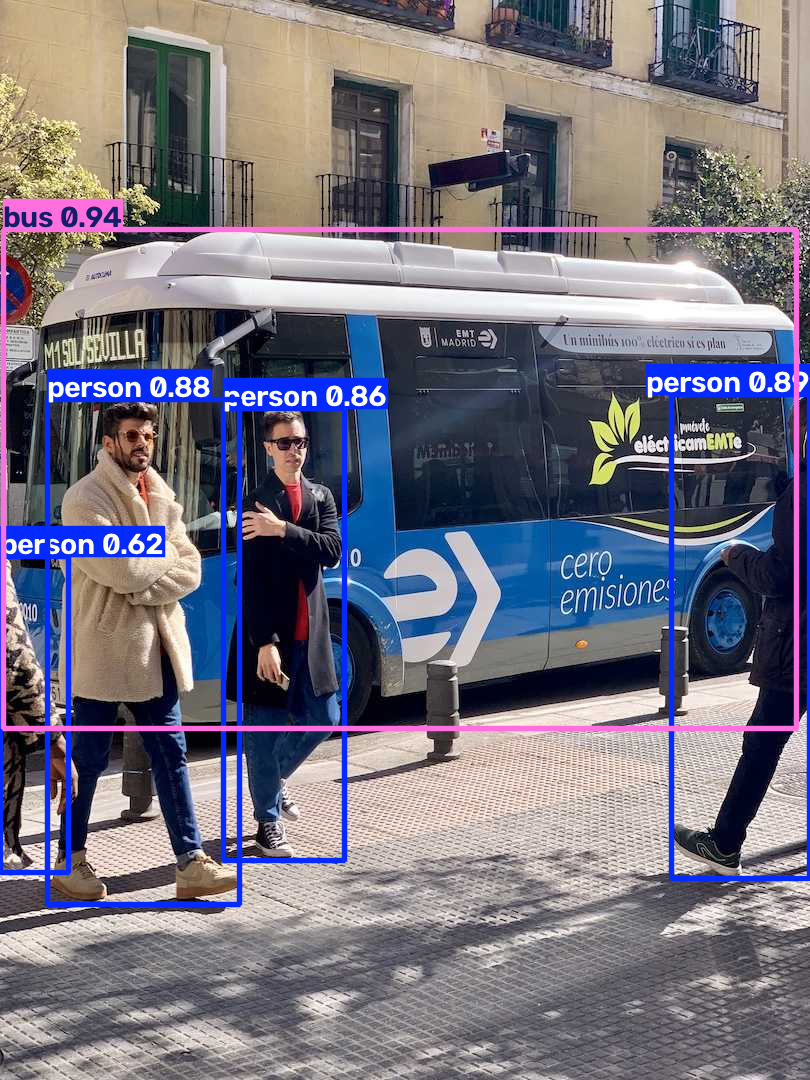

In [ ]:
results = model("https://ultralytics.com/images/bus.jpg")

results[0].show()


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 8.9ms
Speed: 2.1ms preprocess, 8.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)


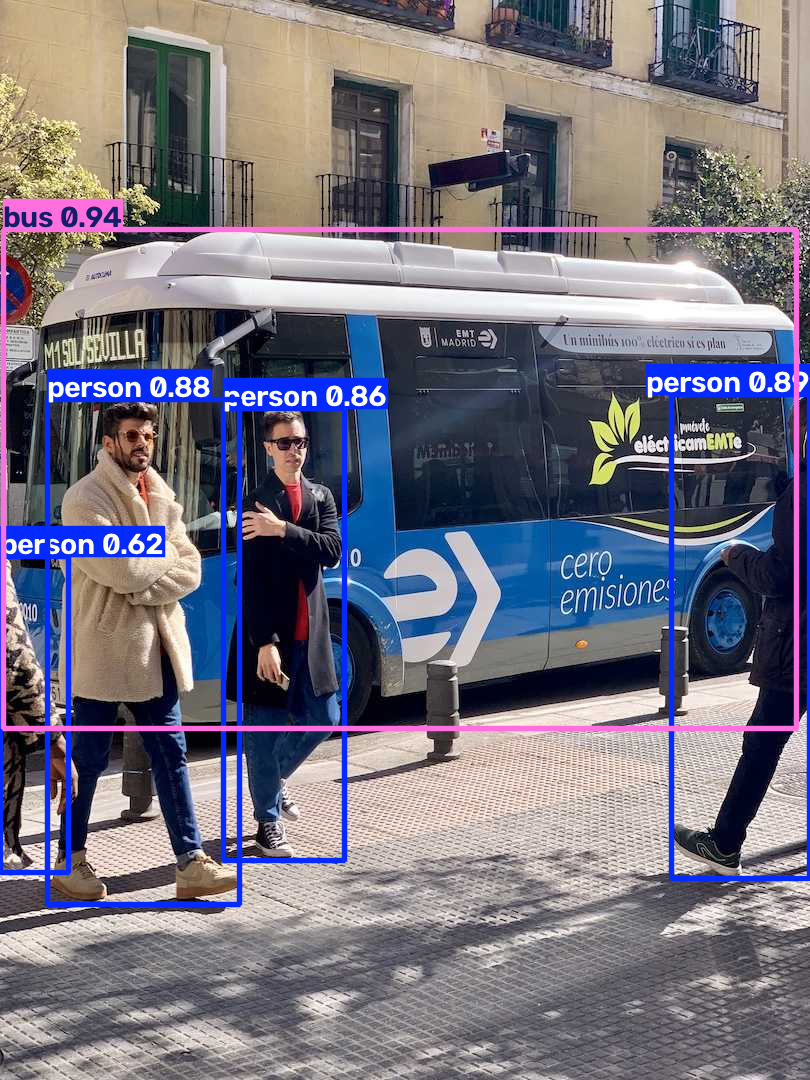

In [ ]:
results = model("https://ultralytics.com/images/bus.jpg")
results[0].show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving picture.jpg to picture.jpg



image 1/1 /content/picture.jpg: 416x640 7 persons, 1 bus, 143.7ms
Speed: 3.9ms preprocess, 143.7ms inference, 2.3ms postprocess per image at shape (1, 3, 416, 640)


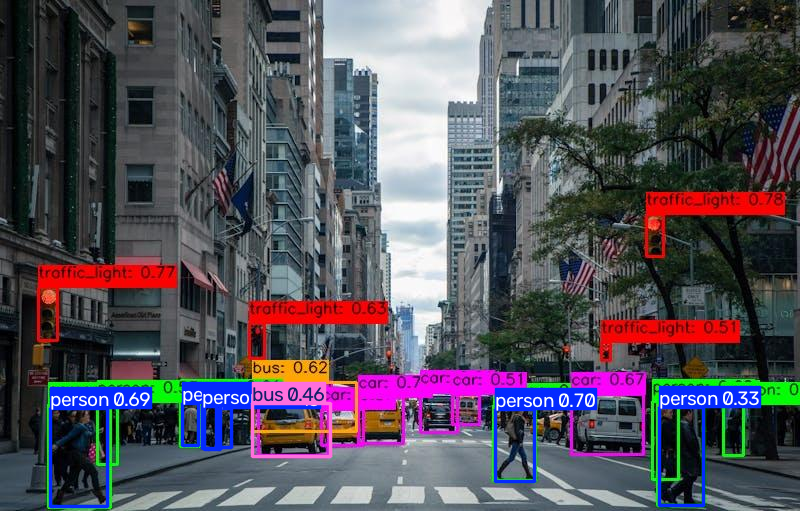

In [ ]:
image_path = list(uploaded.keys())[0]

results = model(image_path)

results[0].show()

In [ ]:
for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = model.names[class_id]

        print(f"{class_name}: {confidence:.2f}")

person: 0.70
person: 0.69
bus: 0.46
person: 0.33
person: 0.33
person: 0.29
person: 0.26
person: 0.25


In [ ]:
total_objects = 0

for result in results:
    total_objects += len(result.boxes)

print("Total objects detected:", total_objects)

Total objects detected: 8


In [ ]:
# Total detected objects
total_objects = len(results[0].boxes)

# Inference time in milliseconds
inference_time = results[0].speed["inference"]

print("Total Objects Detected:", total_objects)
print("Inference Time:", inference_time, "ms")
print("FPS:", 1000 / inference_time)

Total Objects Detected: 8
Inference Time: 143.735893999974 ms
FPS: 6.957204440528828


In [ ]:
import pandas as pd

thresholds = [0.25, 0.40, 0.50, 0.60, 0.70]

data = []

for threshold in thresholds:
    result = model(image_path, conf=threshold, verbose=False)[0]
    count = len(result.boxes)

    data.append({
        "Confidence Threshold": threshold,
        "Objects Detected": count
    })

df = pd.DataFrame(data)

print(df)

   Confidence Threshold  Objects Detected
0                  0.25                 8
1                  0.40                 3
2                  0.50                 2
3                  0.60                 2
4                  0.70                 1


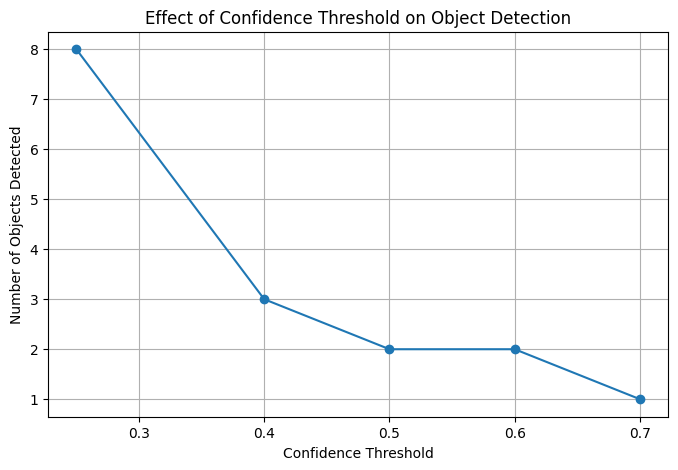

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    df["Confidence Threshold"],
    df["Objects Detected"],
    marker="o"
)

plt.xlabel("Confidence Threshold")
plt.ylabel("Number of Objects Detected")
plt.title("Effect of Confidence Threshold on Object Detection")
plt.grid(True)

plt.show()

In [ ]:
from collections import Counter

result = results[0]

detected_classes = []

for box in result.boxes:
    class_id = int(box.cls[0])
    class_name = model.names[class_id]
    detected_classes.append(class_name)

class_counts = Counter(detected_classes)

print("Class-wise Detection:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Class-wise Detection:
person: 7
bus: 1


In [ ]:
results_table = {
    "Metric": [
        "Total Objects Detected",
        "Person Detected",
        "Bus Detected",
        "Inference Time (ms)",
        "Approx. FPS"
    ],
    "Value": [
        8,
        7,
        1,
        143.7359,
        6.9572
    ]
}

final_df = pd.DataFrame(results_table)

print(final_df.to_string(index=False))

                Metric    Value
Total Objects Detected   8.0000
       Person Detected   7.0000
          Bus Detected   1.0000
   Inference Time (ms) 143.7359
           Approx. FPS   6.9572


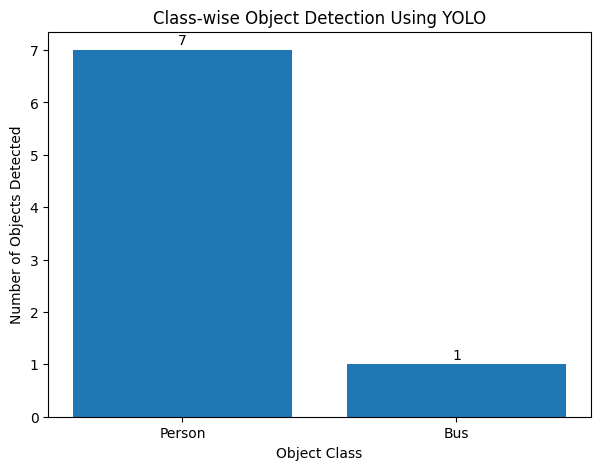

In [ ]:
import matplotlib.pyplot as plt

objects = ["Person", "Bus"]
counts = [7, 1]

plt.figure(figsize=(7, 5))
plt.bar(objects, counts)

plt.xlabel("Object Class")
plt.ylabel("Number of Objects Detected")
plt.title("Class-wise Object Detection Using YOLO")

for i, count in enumerate(counts):
    plt.text(i, count + 0.1, str(count), ha="center")

plt.show()

In [ ]:
import time
import pandas as pd

# Same test image
test_images = [image_path]

results_data = []

for img in test_images:
    result = model(img, verbose=False)[0]

    objects = len(result.boxes)
    inference = result.speed["inference"]
    fps = 1000 / inference

    results_data.append({
        "Image": img,
        "Objects Detected": objects,
        "Inference Time (ms)": round(inference, 2),
        "FPS": round(fps, 2)
    })

multi_df = pd.DataFrame(results_data)

print(multi_df.to_string(index=False))

      Image  Objects Detected  Inference Time (ms)    FPS
picture.jpg                 8                 9.85 101.56


In [ ]:
import numpy as np

times = []

# First run for warm-up
model(image_path, verbose=False)

# Run 10 times
for i in range(10):
    result = model(image_path, verbose=False)[0]
    times.append(result.speed["inference"])

average_time = np.mean(times)
average_fps = 1000 / average_time

print("Inference times:", [round(t, 2) for t in times])
print("Average Inference Time:", round(average_time, 2), "ms")
print("Average FPS:", round(average_fps, 2))

Inference times: [15.6, 10.7, 10.93, 11.63, 11.21, 10.79, 10.05, 9.96, 10.46, 10.64]
Average Inference Time: 11.2 ms
Average FPS: 89.31


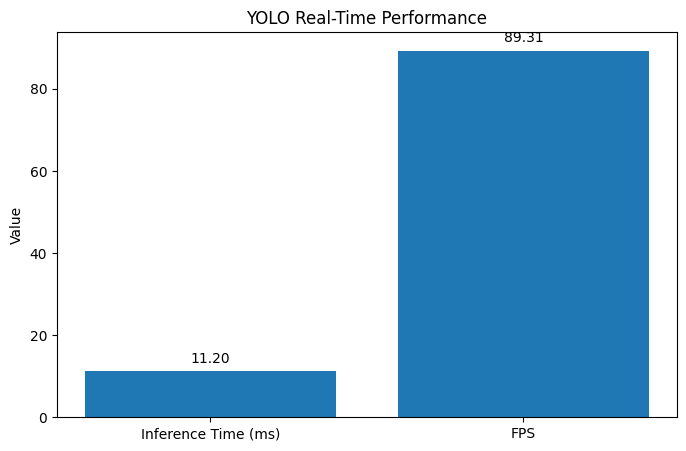

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Inference Time (ms)", "FPS"]
values = [11.20, 89.31]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values)

plt.ylabel("Value")
plt.title("YOLO Real-Time Performance")

for i, value in enumerate(values):
    plt.text(i, value + 2, f"{value:.2f}", ha="center")

plt.show()